In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **EDA**


In [4]:
df = pd.read_csv('/content/Bengkod-Depresi.csv')

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0.0


In [5]:
#informasi
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23972 entries, 0 to 23971
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     23972 non-null  int64  
 1   Gender                                 23972 non-null  object 
 2   Age                                    23972 non-null  int64  
 3   City                                   23972 non-null  object 
 4   Profession                             23972 non-null  object 
 5   Academic Pressure                      23972 non-null  int64  
 6   Work Pressure                          23972 non-null  int64  
 7   CGPA                                   23972 non-null  float64
 8   Study Satisfaction                     23972 non-null  int64  
 9   Job Satisfaction                       23972 non-null  int64  
 10  Sleep Duration                         23971 non-null  object 
 11  Di

(23972, 18)

In [6]:
#mising value
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


Missing Value

Berdasarkan pengecekan, ditemukan adanya missing value pada beberapa kolom. Missing value ini perlu ditangani pada tahap preprocessing agar tidak mempengaruhi performa model.

In [7]:
#duplikasi
df.duplicated().sum()

np.int64(0)

Duplikasi

Terdapat sejumlah data duplikat dalam dataset yang berpotensi menyebabkan bias, sehingga perlu dihapus pada tahap preprocessing.

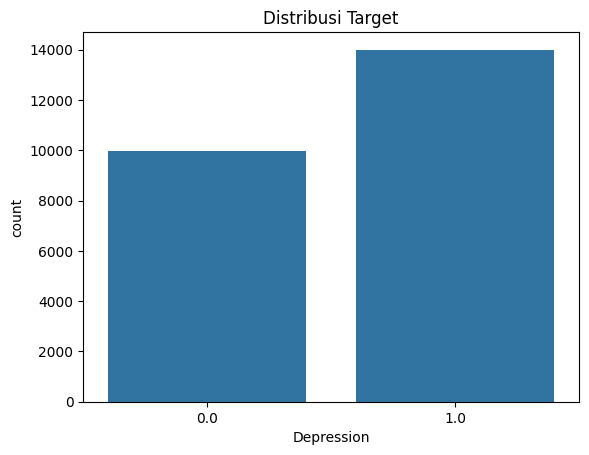

,count
Depression,
1.0,14000
0.0,9971


In [8]:
#distribusi target
sns.countplot(x='Depression', data=df)
plt.title("Distribusi Target")
plt.show()

df['Depression'].value_counts()

Distribusi target menunjukkan masih dalam rentang normal.

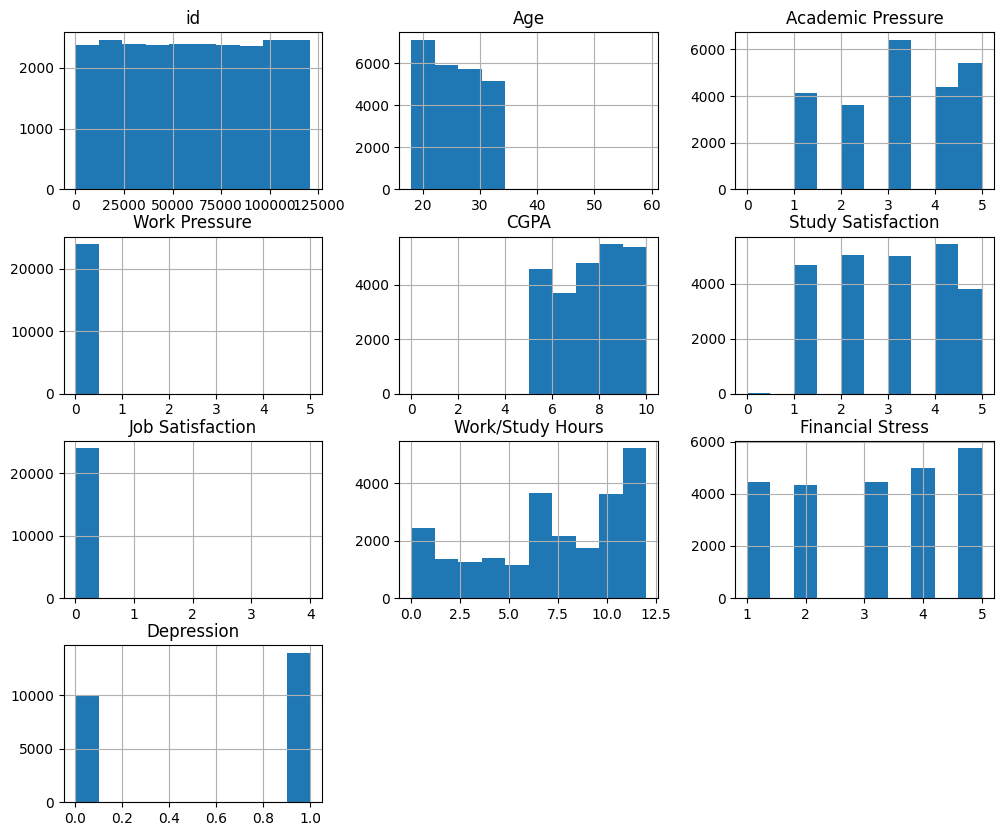

In [9]:
#distribusi numerik
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12,10))
plt.show()

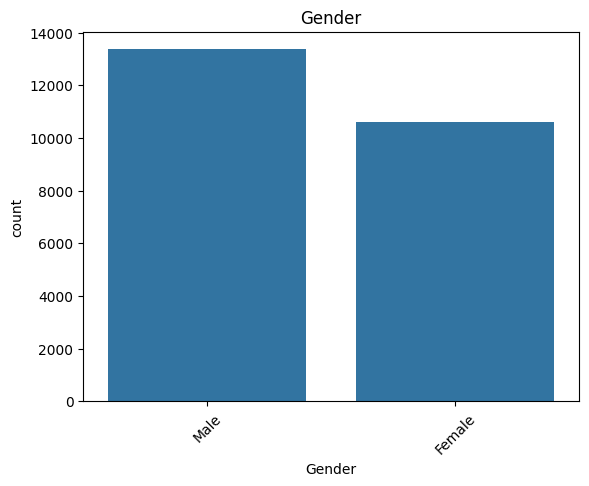

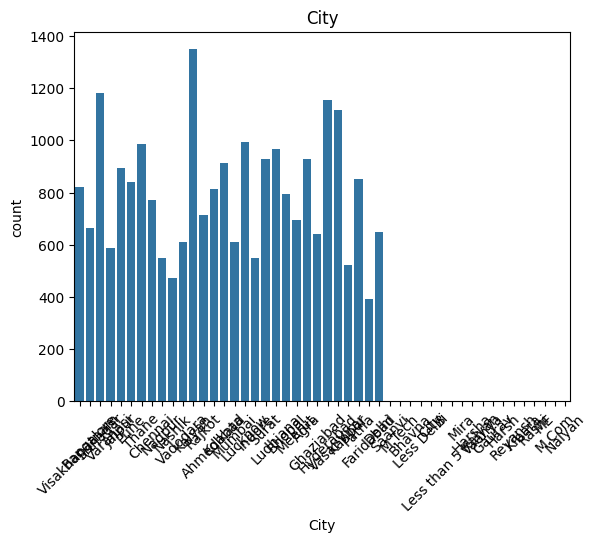

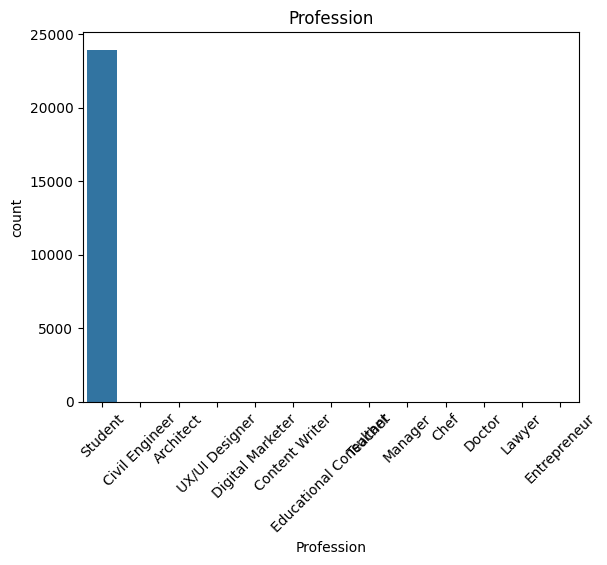

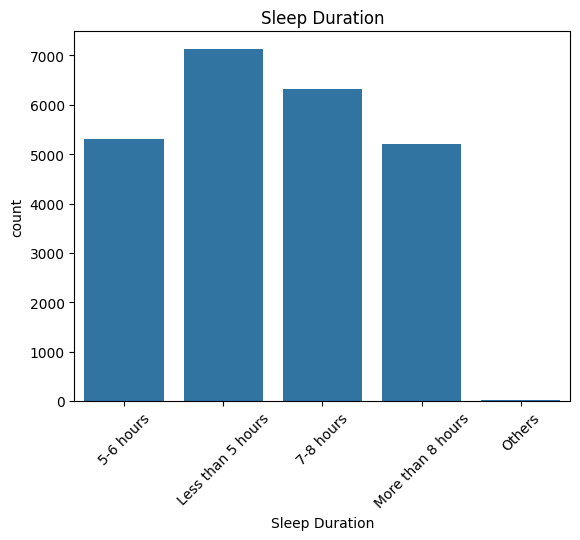

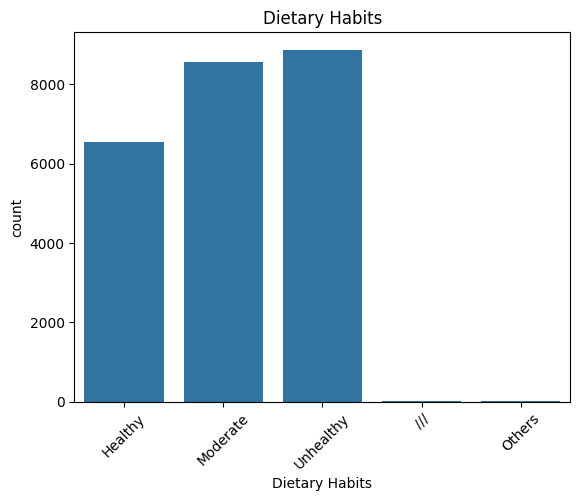

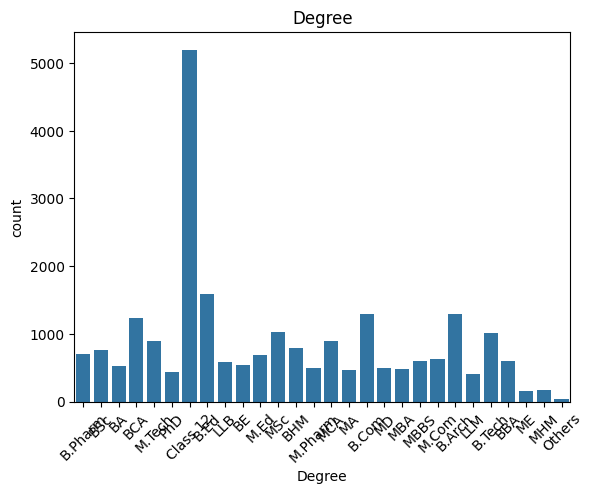

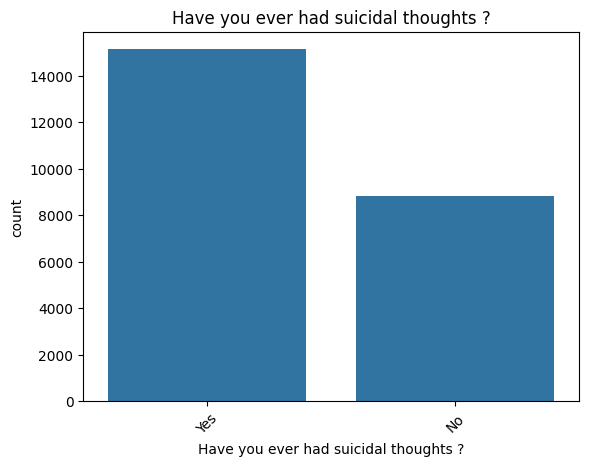

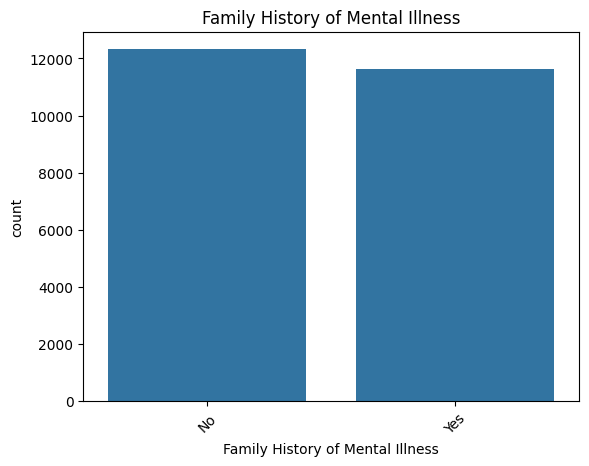

In [10]:
#distribusi kategorik
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

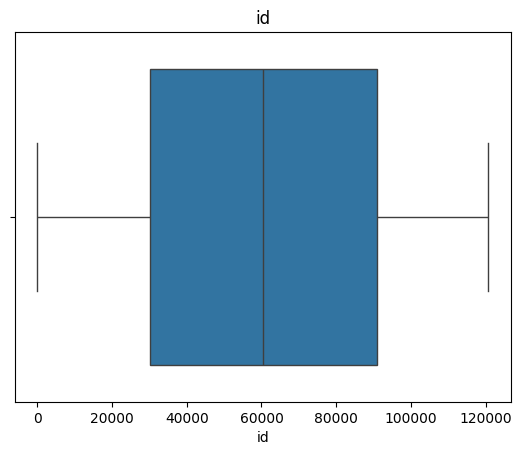

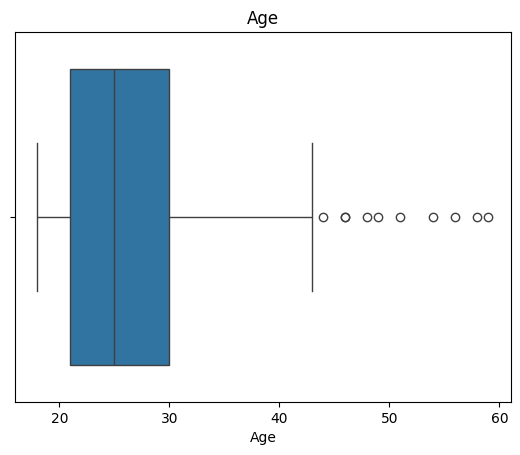

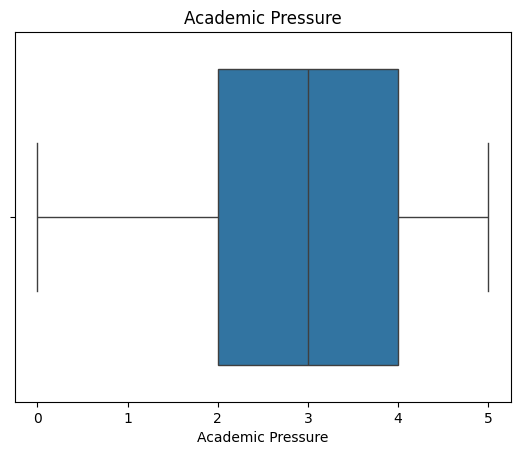

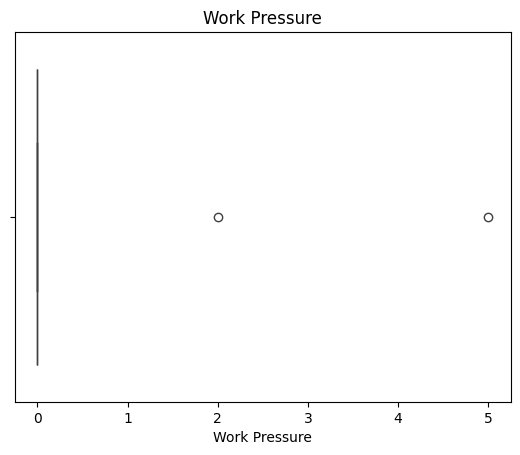

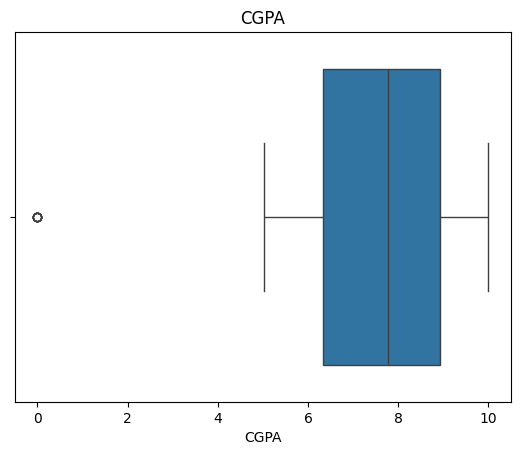

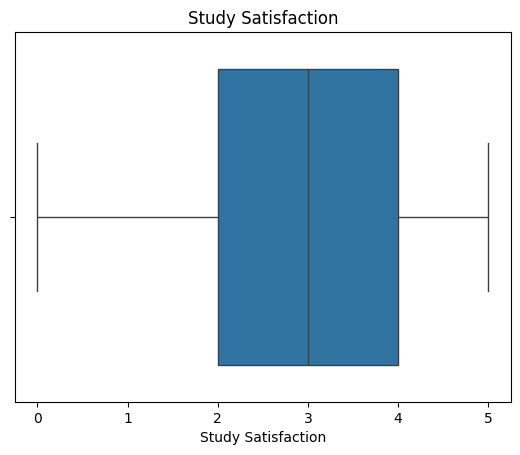

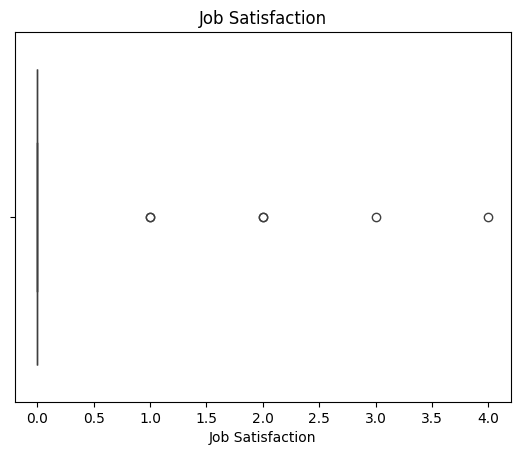

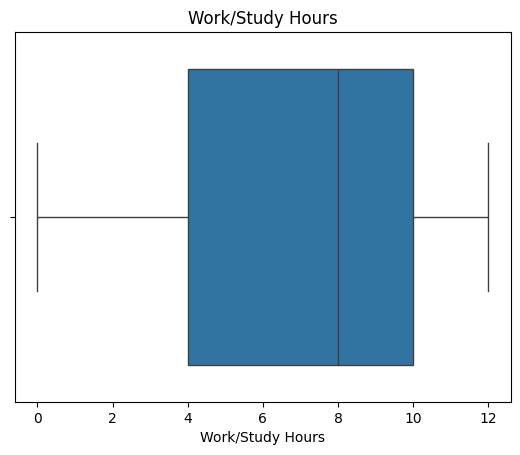

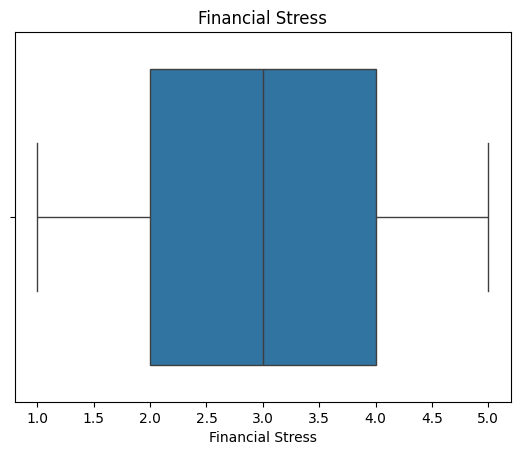

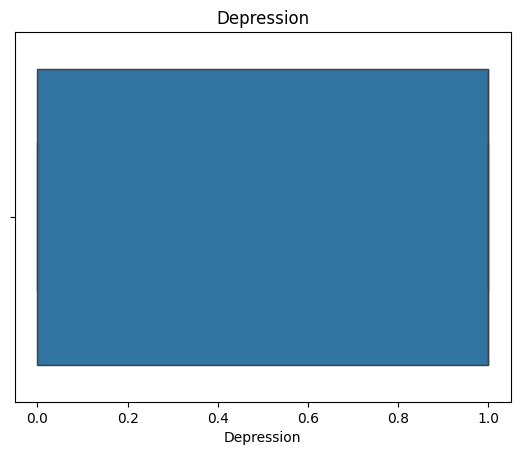

In [11]:
#outlier
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Berdasarkan hasil boxplot, ditemukan outlier dan akan dilakukan preprocessing

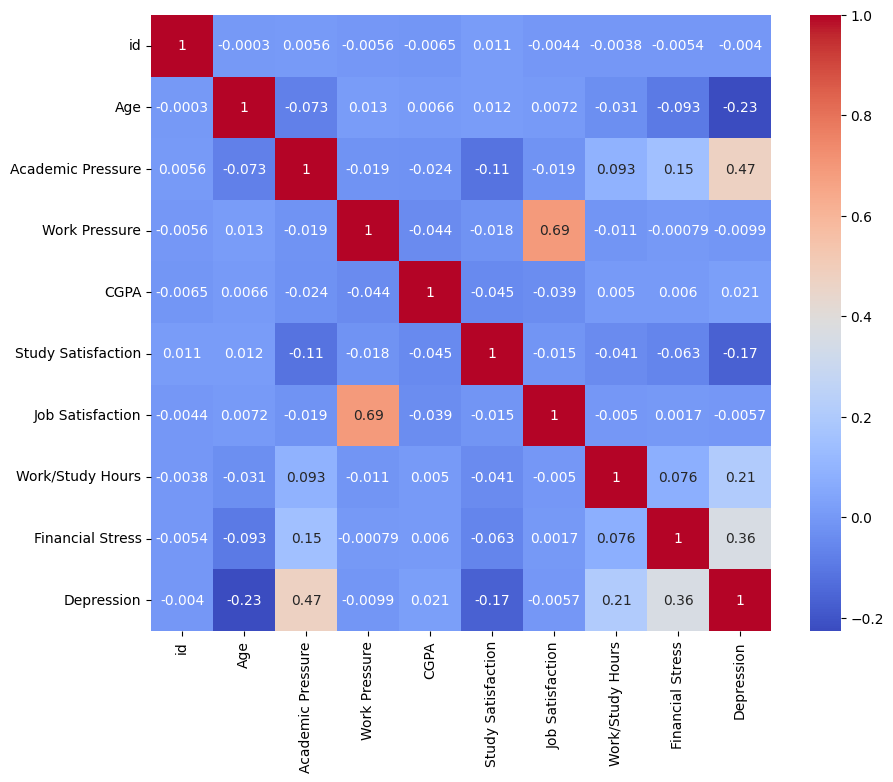

In [12]:
#korelasi
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

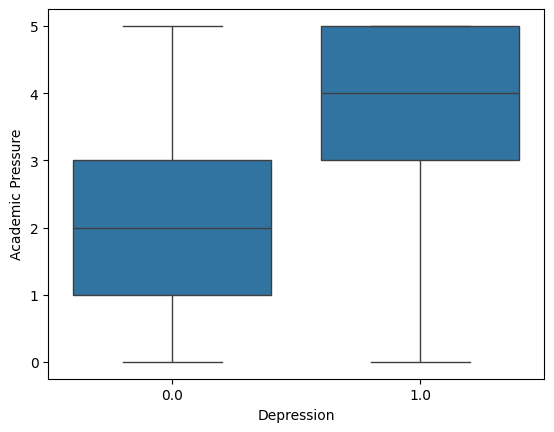

In [13]:
sns.boxplot(x='Depression', y='Academic Pressure', data=df)
plt.show()

Korelasi Tekanan Akademik:

Terdapat pola kuat di mana mahasiswa dengan skor Academic Pressure di atas 3 cenderung memiliki status Depression = 1. Hal ini menunjukkan bahwa beban studi adalah faktor risiko utama, sehingga fitur ini akan diprioritaskan dalam modeling.

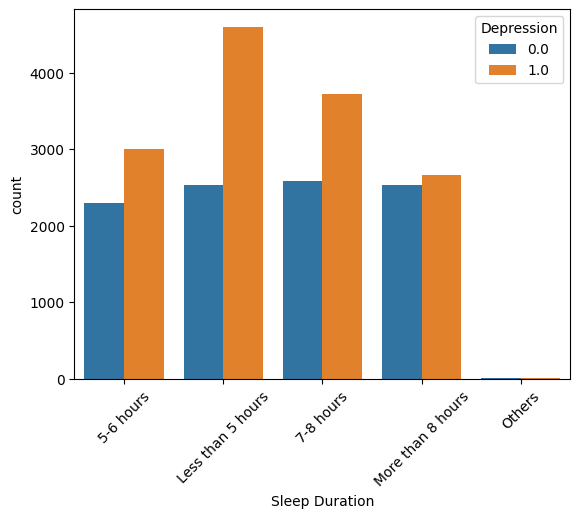

In [14]:
sns.countplot(x='Sleep Duration', hue='Depression', data=df)
plt.xticks(rotation=45)
plt.show()

Pola Durasi Tidur:

Mahasiswa yang melaporkan durasi tidur kurang dengan contoh kurang dari 5 jam memiliki prevalensi depresi yang lebih tinggi dibandingkan mereka yang tidur cukup. Oleh karena itu, fitur Sleep Duration akan dipertahankan sebagai prediktor penting.

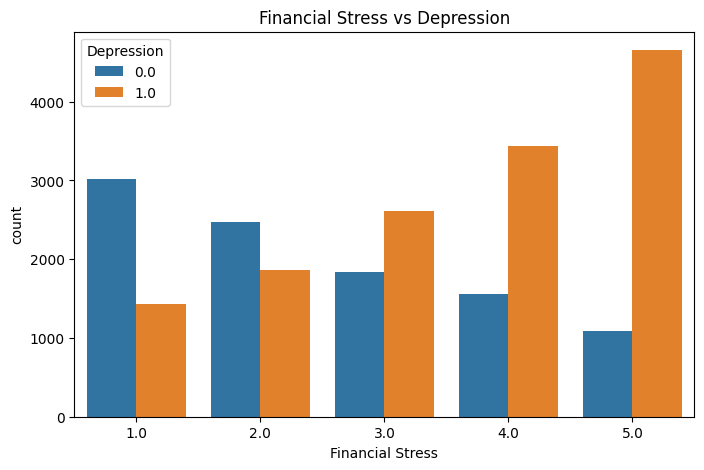

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Financial Stress', hue='Depression', data=df)
plt.title("Financial Stress vs Depression")
plt.show()

Dampak Stres Finansial:

Data menunjukkan adanya kaitan antara tingkat Financial Stress yang tinggi dengan munculnya pikiran bunuh diri (Suicidal Thoughts). Insight ini mendasari keputusan untuk melakukan feature encoding yang tepat pada variabel kategorikal agar model dapat menangkap hubungan ini dengan akurat.

kesimpulan

Berdasarkan hasil EDA, ditemukan bahwa faktor-faktor seperti tekanan akademik, durasi tidur, dan stres finansial memiliki hubungan yang signifikan terhadap kondisi depresi mahasiswa. Selain itu, terdapat beberapa permasalahan pada data seperti missing value dan duplikasi ditangani sebelum tahap modeling. Oleh karena itu, tahap preprocessing menjadi penting untuk meningkatkan kualitas data dan performa model pada tahap selanjutnya.

## **DIRECT MODELING**

Tahap ini bertujuan untuk membangun beberapa model machine learning secara langsung tanpa preprocessing lanjutan sebagai baseline. Hasil dari model ini akan digunakan sebagai pembanding untuk mengevaluasi efektivitas preprocessing dan feature engineering pada tahap berikutnya.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report

In [17]:
#data prepraration
df_model = df.copy()

# handle missing
df_model.dropna(inplace=True)

# encoding kategorik
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

In [18]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Depression', axis=1)
y = df_model['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
#model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

Logistic Regression: Dipilih sebagai model baseline (dasar) untuk menguji sejauh mana variabel target Depression dapat dijelaskan melalui hubungan linear sederhana.


Decision Tree: Algoritma ini sangat baik dalam menangani data yang memiliki pola non-linear dan mudah diinterpretasikan untuk melihat fitur mana yang paling berpengaruh secara hierarkis.


Random Forest: Sebagai model ensemble, Random Forest digunakan untuk meningkatkan akurasi dan mengurangi risiko overfitting yang sering terjadi pada Decision Tree tunggal.


KNN (K-Nearest Neighbors): Model ini efektif untuk mengklasifikasikan status depresi mahasiswa berdasarkan tingkat kemiripan (jarak) dengan profil mahasiswa lainnya.


Naive Bayes (GaussianNB): Dipilih karena efisiensinya dalam menangani fitur-fitur yang bersifat independen dan seringkali memberikan hasil yang sangat baik pada dataset berbasis survei atau kondisi mental.

In [20]:
#train eval
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

import pandas as pd
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.841051,0.846766,0.884713,0.865323
2,Random Forest,0.834793,0.842525,0.877846,0.859823
4,Naive Bayes,0.812265,0.803183,0.893748,0.846049
1,Decision Tree,0.762829,0.790036,0.802313,0.796127
3,KNN,0.519608,0.572409,0.662812,0.614302


hasil

Berdasarkan hasil evaluasi, model Logistic Regression menunjukkan performa terbaik dibandingkan model lainnya dengan accuracy sebesar 0.84 dan F1 Score tertinggi sebesar 0.86.

pada dataset ini Logistic Regression mampu memberikan hasil yang lebih baik. Hal ini menunjukkan bahwa pola dalam dataset cenderung bersifat linear sehingga dapat ditangkap dengan baik oleh Logistic Regression.

Selain itu, Logistic Regression memiliki nilai recall yang lebih tinggi pada kelas depresi, yang berarti model ini lebih baik dalam mendeteksi individu yang mengalami depresi. Hal ini sangat penting dalam konteks masalah kesehatan mental, di mana kesalahan dalam mendeteksi kasus positif harus diminimalkan.

Berdasarkan hasil direct modeling, Logistic Regression dipilih sebagai model terbaik karena memiliki nilai accuracy dan F1 Score tertinggi dibandingkan model lainnya. Selain itu, model ini juga menunjukkan performa yang lebih baik dalam mendeteksi kelas depresi. Hasil ini menunjukkan bahwa dataset memiliki pola yang relatif sederhana dan dapat ditangkap dengan baik oleh model linear.

# Modeling Dengan Preprocessing  

In [21]:
from sklearn.preprocessing import StandardScaler

df_prep = df.copy()

In [22]:
#feature enginering
# Membuat fitur total tekanan mental
df['Total_Pressure_Score'] = df['Academic Pressure'] + df['Work Pressure'] + df['Financial Stress']

# Tambahkan +1 agar tidak terjadi pembagian dengan nol
df['Pressure_Satisfaction_Ratio'] = df['Academic Pressure'] / (df['Study Satisfaction'] + 1)


In [23]:
#handle missing
df_prep.dropna(inplace=True)

#handle duplikasi
df.drop_duplicates(inplace=True)

In [24]:
# penghapusan outlier
features_to_clean = ['Age', 'Work Pressure', 'CGPA', 'Job Satisfaction']

print(f"Jumlah baris sebelum cleaning: {len(df)}")

for col in features_to_clean:
    # Menghitung Kuartil 1 (25%) dan Kuartil 3 (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range
    IQR = Q3 - Q1

    # Menentukan Batas Bawah dan Batas Atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data: hanya ambil yang berada di dalam rentang batas
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Jumlah baris setelah cleaning: {len(df)}")
print("Outlier pada fitur Age, Work Pressure, CGPA, dan Job Satisfaction telah dihapus.")

Jumlah baris sebelum cleaning: 23972
Jumlah baris setelah cleaning: 23953
Outlier pada fitur Age, Work Pressure, CGPA, dan Job Satisfaction telah dihapus.


In [25]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_prep.select_dtypes(include='object').columns:
    df_prep[col] = le.fit_transform(df_prep[col])

In [26]:
#slpit data
X = df_prep.drop('Depression', axis=1)
y = df_prep['Depression']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [29]:
results_prep = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results_prep.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_prep_df = pd.DataFrame(results_prep)
results_prep_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.843346,0.845916,0.890857,0.867805
2,Random Forest,0.837714,0.845193,0.880014,0.862252
3,KNN,0.812891,0.818678,0.868088,0.842659
1,Decision Tree,0.768252,0.796562,0.803759,0.800144
4,Naive Bayes,0.577180,0.577180,1.000000,0.731914


hasil

Berdasarkan hasil modeling dengan preprocessing, terlihat bahwa preprocessing memberikan dampak yang berbeda pada setiap model. Model seperti Logistic Regression dan Random Forest mengalami peningkatan performa meskipun tidak signifikan, yang menunjukkan bahwa model tersebut sudah cukup stabil pada tahap direct modeling.

Sementara itu, Decision Tree dan Naive Bayes menunjukkan peningkatan, karena model tersebut tidak terlalu dipengaruhi oleh skala data.

KNN mengalami peningkatan performa yang signifikan setelah dilakukan preprocessing. Hal ini disebabkan karena KNN sangat bergantung pada perhitungan jarak antar data, sehingga proses scaling, penghapusan outlier, dan pemilihan fitur yang relevan sangat mempengaruhi hasil prediksi

Logistic Regression tetap menjadi model terbaik dengan nilai accuracy dan F1 Score tertinggi. Hal ini menunjukkan bahwa model ini mampu menangkap pola data dengan baik bahkan setelah dilakukan preprocessing.

# Feature Selection

In [30]:
df_fs = df.copy()

In [31]:
df_fs.drop('id', axis=1, inplace=True)

In [38]:
# handle missing value
df_fs.dropna(inplace=True)

In [39]:
#encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_fs.select_dtypes(include='object').columns:
    df_fs[col] = le.fit_transform(df_fs[col])

In [40]:
#korelasi fitur selection
import pandas as pd

corr = df_fs.corr()

target_corr = corr['Depression'].sort_values(ascending=False)
print(target_corr)

Depression                               1.000000
Total_Pressure_Score                     0.548565
Have you ever had suicidal thoughts ?    0.547205
Academic Pressure                        0.473505
Pressure_Satisfaction_Ratio              0.417730
Financial Stress                         0.360624
Dietary Habits                           0.208395
Work/Study Hours                         0.206703
Family History of Mental Illness         0.055567
CGPA                                     0.021205
Gender                                   0.002446
Degree                                  -0.012773
Profession                              -0.015061
Sleep Duration                          -0.018409
City                                    -0.024177
Study Satisfaction                      -0.168218
Age                                     -0.225585
Work Pressure                                 NaN
Job Satisfaction                              NaN
Name: Depression, dtype: float64


In [41]:
#ambil fitur yg kuat
selected_corr = target_corr[abs(target_corr) > 0.1].index
selected_corr = selected_corr.drop('Depression')

print("Fitur dari correlation:")
print(selected_corr)

Fitur dari correlation:
Index(['Total_Pressure_Score', 'Have you ever had suicidal thoughts ?',
       'Academic Pressure', 'Pressure_Satisfaction_Ratio', 'Financial Stress',
       'Dietary Habits', 'Work/Study Hours', 'Study Satisfaction', 'Age'],
      dtype='object')


In [42]:
#fitur importance
from sklearn.ensemble import RandomForestClassifier

X = df_fs.drop('Depression', axis=1)
y = df_fs['Depression']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

Have you ever had suicidal thoughts ?    0.188858
Total_Pressure_Score                     0.126037
Pressure_Satisfaction_Ratio              0.091056
Age                                      0.079454
CGPA                                     0.079371
Academic Pressure                        0.074778
City                                     0.066903
Work/Study Hours                         0.064818
Degree                                   0.057971
Financial Stress                         0.048646
Dietary Habits                           0.033027
Sleep Duration                           0.032283
Study Satisfaction                       0.026747
Family History of Mental Illness         0.015208
Gender                                   0.014608
Profession                               0.000235
Job Satisfaction                         0.000000
Work Pressure                            0.000000
dtype: float64


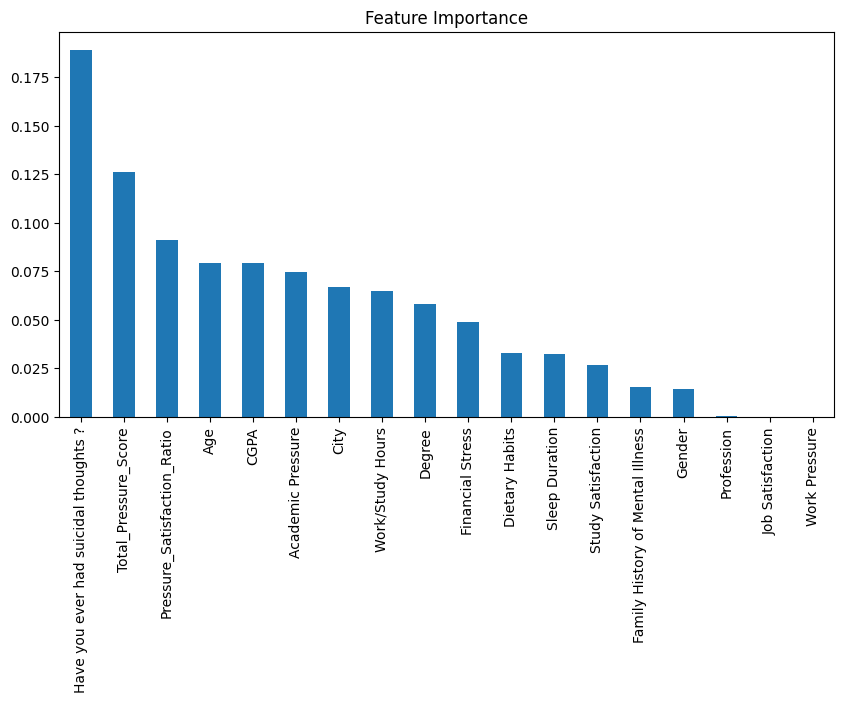

In [43]:
#visualisasi
import matplotlib.pyplot as plt

importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [44]:
#ambil top fitur
top_features = importance.head(8).index
print("Top Features:")
print(top_features)

Top Features:
Index(['Have you ever had suicidal thoughts ?', 'Total_Pressure_Score',
       'Pressure_Satisfaction_Ratio', 'Age', 'CGPA', 'Academic Pressure',
       'City', 'Work/Study Hours'],
      dtype='object')


In [45]:
#fitur selection final
final_features = list(top_features)
print("Final Features:", final_features)

Final Features: ['Have you ever had suicidal thoughts ?', 'Total_Pressure_Score', 'Pressure_Satisfaction_Ratio', 'Age', 'CGPA', 'Academic Pressure', 'City', 'Work/Study Hours']


In [46]:
#train ulang dg model terpilih
X_selected = df_fs[final_features]
y = df_fs['Depression']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42)

In [48]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
#train model lr


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8390396659707724
F1 Score: 0.866770347330223


hasil

Berdasarkan proses feature selection menggunakan metode korelasi dan feature importance, diperoleh beberapa fitur yang memiliki kontribusi paling besar terhadap variabel target Depression.

Setelah dilakukan feature selection, terjadi sedikit penurunan performa model Namun penurunan ini tidak signifikan, sehingga dapat disimpulkan bahwa fitur yang dihilangkan sebelumnya memang tidak memiliki kontribusi besar terhadap model.

Selain itu, model tetap mampu mempertahankan performa yang baik dengan jumlah fitur yang lebih sedikit, yang menunjukkan bahwa fitur yang dipilih merupakan fitur yang relevan dan informatif.

Hasil ini menunjukkan bahwa terdapat redundansi pada beberapa fitur dalam dataset, sehingga feature selection berhasil menghilangkan fitur yang tidak terlalu berkontribusi tanpa mengorbankan performa secara signifikan.

# **Hyperparameter Tuning**

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# parameter yang diuji
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='f1')

In [51]:
print("Best Params:", grid.best_params_)

Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


C = 0.01
Regularisasi lebih kuat
Model lebih “sederhana”
Menghindari overfitting


Model memilih generalisasi daripada terlalu mengikuti data training


L2 Regularization

Mengontrol bobot fitur
Menghindari model terlalu kompleks


lbfgs

Solver standar yang stabil


In [52]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8400835073068893
F1 Score: 0.8677942699344149


Berdasarkan hasil perbandingan antara model setelah feature selection dan setelah dilakukan hyperparameter tuning, terlihat bahwa terjadi peningkatan performa meskipun tidak signifikan.

Peningkatan ini menunjukkan bahwa proses hyperparameter tuning berhasil mengoptimalkan parameter model sehingga menghasilkan performa yang lebih baik. Meskipun peningkatannya kecil, hal ini menunjukkan bahwa model telah mencapai kondisi yang lebih optimal dan stabil.

Peningkatan yang tidak signifikan menunjukkan bahwa model sebelumnya sudah berada pada kondisi yang cukup optimal, sehingga ruang peningkatan menjadi terbatas. Hal ini juga menunjukkan bahwa pemilihan fitur pada tahap feature selection sudah cukup efektif.

Model Logistic Regression dengan parameter hasil tuning dipilih sebagai model final karena memberikan performa terbaik dan paling stabil dibandingkan dengan model lainnya.

In [55]:
import joblib

# simpan model
joblib.dump(best_model, 'model.pkl')

# simpan scaler
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']